# Polarization data overview

This notebook loads synthetic polarization datasets at 50 C, 60 C, and 70 C, groups each record by pressure level, and then reuses shared plotting helpers for the comparison figures.

The helper cells below keep file lookup, aggregation, and plotting logic in one place so the analysis cells stay short and easier to rerun.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [12]:
PRESSURES = ("P300", "P400", "P500")
RH_LEVELS = ("RH0", "RH50")

sensor_data_cols = [
    "Time(s)", "I_LOAD", "P_H2", "P_AIR", "HR_AIR_FC",
    "T_H2O_IN", "T_H2O_OUT", "T_H2O_MEAN", "R",
]

pressure_colors = {"P300": "tab:blue", "P400": "tab:orange", "P500": "tab:green"}
pressure_linestyles = {"P300": "-", "P400": "--", "P500": ":"}
temp_colors = {"T50": "tab:blue", "T60": "tab:orange", "T70": "tab:green"}
temp_linestyles = {"T50": "-", "T60": "--", "T70": ":"}
temp_labels = {"T50": "50 C", "T60": "60 C", "T70": "70 C"}
rh_markers = {"RH0": "s", "RH50": "o"}
rh_labels = {"RH0": "RH 0%", "RH50": "RH 50%"}

def find_data_file(filename):
    for path in (Path.cwd() / filename, Path.cwd() / "data" / "rawdata" / filename):
        if path.exists():
            return path

def resolve_data_file(filename):
    path = find_data_file(filename)
    if path is None:
        raise FileNotFoundError(f"Could not locate {filename} from {Path.cwd()}")
    return path

def read_optional_excel(filename):
    path = find_data_file(filename)
    if path is None:
        print(f"Skipping {filename}: file not found from {Path.cwd()}")
        return None
    return pd.read_excel(path)

def empty_pressure_map(): return {pressure: [] for pressure in PRESSURES}
def empty_pressure_rh_map(): return {pressure: {rh: [] for rh in RH_LEVELS} for pressure in PRESSURES}
def collapse_aux_frames(frames): return pd.concat(frames, ignore_index=True).sort_values("Time(s)").reset_index(drop=True) if frames else pd.DataFrame(columns=sensor_data_cols)
def classify_rh_level(rh_series): return "RH50" if abs(float(rh_series.mean()) - 50) <= abs(float(rh_series.mean())) else "RH0"
def curve_frame(points): return pd.DataFrame(points, columns=["VFC", "I_LOAD"]).sort_values("I_LOAD")
def series_entry(points, **style): return None if not points else (lambda df: (df["I_LOAD"], df["VFC"], style))(curve_frame(points))
def compact_series(entries): return [entry for entry in entries if entry is not None]

def load_temperature_dataset(filename, pressure_floor=None):
    pola_data, aux_data = empty_pressure_rh_map(), empty_pressure_map()
    for sheet_name, record in pd.read_excel(resolve_data_file(filename), sheet_name=None).items():
        if "REC" not in sheet_name:
            continue
        pressure_value = int(round(record["P_H2"].mean(), -2))
        if pressure_floor is not None and pressure_value < pressure_floor:
            pressure_value = 300
        pressure_key = f"P{pressure_value}"
        if pressure_key not in pola_data:
            continue
        rh_key = classify_rh_level(record["HR_AIR_FC"]) if "HR_AIR_FC" in record.columns else "RH50"
        pola_data[pressure_key][rh_key].append((record["VFC"].mean(), record["I_LOAD"].mean()))
        aux_data[pressure_key].append(record[sensor_data_cols])
    return pola_data, {pressure: collapse_aux_frames(frames) for pressure, frames in aux_data.items()}

def finalize_plot(xlabel, ylabel, title, legend_title=None, legend_ncol=1, ylim=None):
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.legend(title=legend_title, ncol=legend_ncol)
    plt.tight_layout()
    plt.show()

def plot_polarization_series(series, title, legend_ncol=1):
    plt.figure(figsize=(10, 7))
    for x_values, y_values, style in series:
        plt.plot(x_values, y_values, **style)
    finalize_plot("Current (A)", "Voltage (V)", title, legend_title=r"$S_c = 2.5, S_a = 1.2$", legend_ncol=legend_ncol)

def plot_full_polarization_map(polarization_data): return plot_polarization_series(compact_series(series_entry(pola_data[pressure][rh_level], marker=rh_markers[rh_level], linewidth=1.8, color=pressure_colors[pressure], linestyle=temp_linestyles[temp_label], label=f"{temp_labels[temp_label]} - {pressure} - {rh_labels[rh_level]}") for temp_label, pola_data in polarization_data.items() for pressure in PRESSURES for rh_level in RH_LEVELS), "Polarization Curves: T50, T60, T70 with RH Levels", legend_ncol=3)
def plot_single_temperature(polarization_data, temp_label): return plot_polarization_series(compact_series(series_entry(polarization_data[temp_label][pressure][rh_level], marker=rh_markers[rh_level], linewidth=1.8, color=pressure_colors[pressure], linestyle=temp_linestyles[temp_label], label=f"{temp_labels[temp_label]} - {pressure} - {rh_labels[rh_level]}") for pressure in PRESSURES for rh_level in RH_LEVELS), f"Polarization Curves: {temp_label} with RH Levels", legend_ncol=3)
def plot_pressure_slice(polarization_data, pressure): return plot_polarization_series(compact_series(series_entry(pola_data[pressure][rh_level], marker=rh_markers[rh_level], linewidth=1.8, color=temp_colors[temp_label], linestyle="-" if rh_level == "RH50" else "--", label=f"{temp_labels[temp_label]} - {rh_labels[rh_level]}") for temp_label, pola_data in polarization_data.items() for rh_level in RH_LEVELS), f"Polarization Curves at {pressure[1:]} mbar - Temperature and RH Effects")

def plot_aux_metric(auxiliary_data, metric, ylabel, title, ylim=None):
    plt.figure(figsize=(9, 6))
    for pressure in PRESSURES:
        for temp_label in ("T50", "T60", "T70"):
            df = auxiliary_data[temp_label][pressure]
            if df.empty:
                continue
            plt.plot(
                df["I_LOAD"],
                df[metric],
                label=f"{temp_labels[temp_label]} - {pressure}",
                color=temp_colors[temp_label],
                linestyle=pressure_linestyles[pressure],
            )
    finalize_plot("Current (A)", ylabel, title, legend_title=r"$S_c = 2.5, S_a = 1.2$", legend_ncol=3, ylim=ylim)

def plot_dual_axis_window(dataframe, hygrometry_col, hygrometry_label, start=0, stop=None, current_ylim=None, voltage_ylim=None):
    view = dataframe.iloc[start:stop].reset_index(drop=True)
    fig, axes = plt.subplots(figsize=(16, 5), ncols=2, nrows=1)
    fig.subplots_adjust(wspace=0.35)

    line_current, = axes[0].plot(view["I_LOAD"], color="#be291e", label="Current")
    axes[0].set_ylabel("Current (A)")
    axes[0].set_xlabel("Time (s)")
    if current_ylim is not None:
        axes[0].set_ylim(*current_ylim)

    ax2 = axes[0].twinx()
    ax2.set_ylabel("Voltage (V)")
    line_voltage, = ax2.plot(view["VFC"], color="#168b06", label="Voltage")
    if voltage_ylim is not None:
        ax2.set_ylim(*voltage_ylim)
    axes[0].legend(handles=[line_current, line_voltage], loc="upper right")

    axes[1].plot(view[hygrometry_col], color="#be291e", label=hygrometry_label)
    axes[1].set_ylabel(f"{hygrometry_label} (%)")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend(loc="upper left" if hygrometry_col == "HR_H2_FC" else "upper right")

def plot_filtered_resistance(dataframe, start=0, stop=None, window=11, ylim=None):
    r_filtered = dataframe["R"].iloc[start:stop].rolling(window=window, center=True, min_periods=1).median()
    plt.figure(figsize=(10, 4))
    plt.plot(r_filtered, color="#1f77b4", label=f"R (median filter, window={window})")
    plt.xlabel("Time (s)")
    plt.ylabel("R")
    plt.legend()
    if ylim is not None:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

In [13]:
temperature_files = {
    "T50": ("SYNTH_T50_N1.xlsx", None),
    "T60": ("SYNTH_T60_N1.xlsx", None),
    "T70": ("SYNTH_T70_N1.xlsx", 380),
}

loaded_data = {
    temp_label: load_temperature_dataset(filename, pressure_floor=pressure_floor)
    for temp_label, (filename, pressure_floor) in temperature_files.items()
}

all_pola_data = {temp_label: data[0] for temp_label, data in loaded_data.items()}
all_aux_data = {temp_label: data[1] for temp_label, data in loaded_data.items()}

pola_data_T50, pola_data_T60, pola_data_T70 = (all_pola_data[temp] for temp in ("T50", "T60", "T70"))
aux_data_T50, aux_data_T60, aux_data_T70 = (all_aux_data[temp] for temp in ("T50", "T60", "T70"))

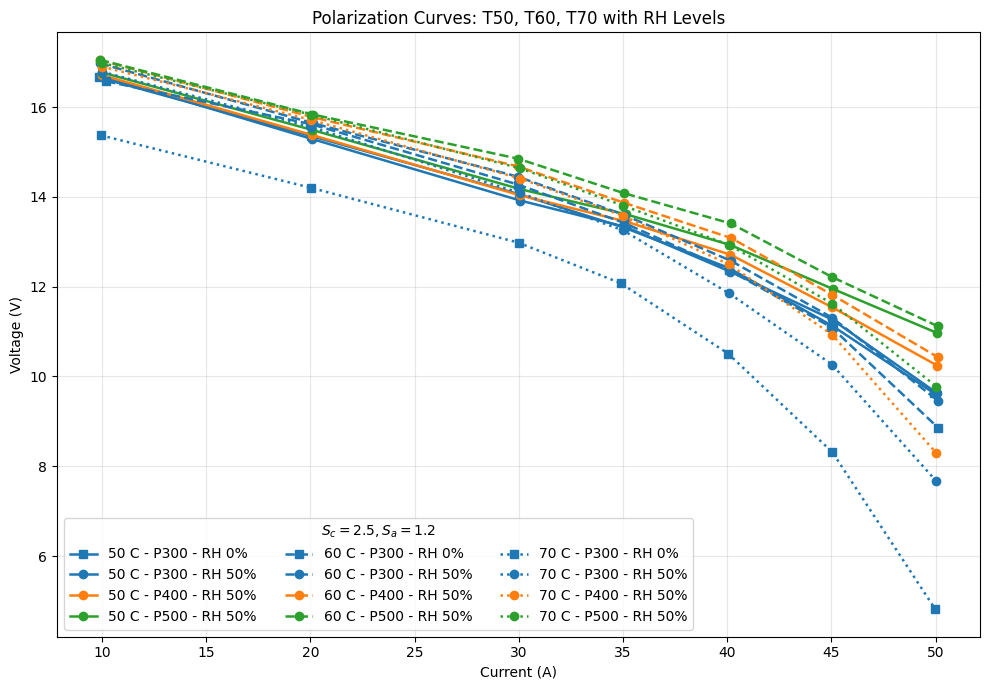

In [14]:
plot_full_polarization_map(all_pola_data)